<a href="https://colab.research.google.com/github/gez2code/dermamnist-hybrid-study/blob/main/DermaMNIST_Manual_FineTuningNew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DermaMNIST: Manual Fine-Tuning Experiments

**Focus**: Find optimal configuration for each architecture

**Architectures to test**:
1. Custom CNN (tune: filters, dropout, depth)
2. ResNet50 Fine-tuned (tune: learning rate, layers to unfreeze, dropout)
3. VGG16 Fine-tuned (tune: learning rate, layers to unfreeze, dropout)
4. EfficientNet Fine-tuned (tune: learning rate, layers to unfreeze, dropout)

**All metrics tracked**: Train, Validation, AND Test (full transparency)

**Strategy**: Run experiment → Check W&B → Adjust parameters → Run again

---

## Setup

In [1]:
!pip install -q medmnist wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.2 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50, VGG16, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from medmnist import DermaMNIST
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print('✓ Imports successful')
print(f'TensorFlow: {tf.__version__}')

✓ Imports successful
TensorFlow: 2.19.0


In [3]:
# Reproducibility
SEED = 42

def set_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()
print(f'✓ Seed: {SEED}')

✓ Seed: 42


## Data Loading

In [4]:
# Load data
print("Loading DermaMNIST...")
train_data = DermaMNIST(split='train', download=True, size=28)
val_data = DermaMNIST(split='val', download=True, size=28)
test_data = DermaMNIST(split='test', download=True, size=28)

# Normalize
x_train = train_data.imgs.astype('float32') / 255.0
x_val = val_data.imgs.astype('float32') / 255.0
x_test = test_data.imgs.astype('float32') / 255.0

# Binary mapping
to_binary = lambda y: np.isin(y, [0, 1, 6]).astype(int)
y_train_bin = to_binary(train_data.labels)
y_val_bin = to_binary(val_data.labels)
y_test_bin = to_binary(test_data.labels)

# One-hot encode
y_train = tf.keras.utils.to_categorical(y_train_bin, 2)
y_val = tf.keras.utils.to_categorical(y_val_bin, 2)
y_test = tf.keras.utils.to_categorical(y_test_bin, 2)

# Class weights
cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_bin),
    y=y_train_bin.flatten()
)
class_weights = {0: cw[0], 1: cw[1]}

print(f'\n✓ Data ready')
print(f'  Train: {x_train.shape}, Malignant: {100*y_train_bin.mean():.1f}%')
print(f'  Val:   {x_val.shape}, Malignant: {100*y_val_bin.mean():.1f}%')
print(f'  Test:  {x_test.shape}, Malignant: {100*y_test_bin.mean():.1f}%')
print(f'  Class weights: Benign={class_weights[0]:.2f}, Malignant={class_weights[1]:.2f}')

Loading DermaMNIST...


100%|██████████| 19.7M/19.7M [00:19<00:00, 1.01MB/s]



✓ Data ready
  Train: (7007, 28, 28, 3), Malignant: 9.8%
  Val:   (1003, 28, 28, 3), Malignant: 9.9%
  Test:  (2005, 28, 28, 3), Malignant: 9.9%
  Class weights: Benign=0.55, Malignant=5.11


In [5]:
# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

print('✓ Augmentation configured')

✓ Augmentation configured


## Model Builders

In [6]:
def build_custom_cnn(filters_base=32, depth=3, dropout=0.5, dense_units=512):
    """
    Custom CNN with tunable architecture

    Tunable parameters:
    - filters_base: Starting filters (32, 64, 128)
    - depth: Number of conv blocks (2, 3, 4)
    - dropout: Dropout rate (0.3, 0.5, 0.7)
    - dense_units: Dense layer size (256, 512, 1024)
    """
    model = models.Sequential([layers.Input(shape=(28, 28, 3))])

    # Conv blocks
    for i in range(depth):
        filters = filters_base * (2 ** i)
        model.add(layers.Conv2D(filters, (3, 3), activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Dropout(dropout * (0.5 + i*0.25)))

    # Classification head
    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(2, activation='softmax'))

    return model

print('✓ Custom CNN builder ready')

✓ Custom CNN builder ready


In [7]:
def build_transfer_model(base_name='resnet50', dropout=0.5,
                         unfreeze_layers=None, dense_units=256):
    """
    Transfer learning model with fine-tuning control

    Tunable parameters:
    - base_name: 'resnet50', 'vgg16', 'efficientnet'
    - dropout: Dropout rate (0.3, 0.5, 0.7)
    - unfreeze_layers: Number of layers to unfreeze from top
                       None = unfreeze all (full fine-tuning)
                       0 = freeze all (feature extraction only)
                       N = unfreeze last N layers
    - dense_units: Dense layer size (128, 256, 512)
    """
    # Input + upsampling
    inputs = layers.Input(shape=(28, 28, 3))
    x = layers.UpSampling2D(size=(2, 2))(inputs)

    # Load base model
    if base_name == 'resnet50':
        base = ResNet50(include_top=False, weights='imagenet',
                       input_shape=(56, 56, 3), pooling='avg')
    elif base_name == 'vgg16':
        base = VGG16(include_top=False, weights='imagenet',
                    input_shape=(56, 56, 3), pooling='avg')
    elif base_name == 'efficientnet':
        base = EfficientNetB0(include_top=False, weights='imagenet',
                             input_shape=(56, 56, 3), pooling='avg')
    else:
        raise ValueError(f"Unknown base: {base_name}")

    # Configure layer freezing
    if unfreeze_layers is None:
        # Unfreeze all layers (full fine-tuning)
        base.trainable = True
        trainable_status = "all_layers"
    elif unfreeze_layers == 0:
        # Freeze all (feature extraction only)
        base.trainable = False
        trainable_status = "frozen"
    else:
        # Unfreeze last N layers
        base.trainable = True
        for layer in base.layers[:-unfreeze_layers]:
            layer.trainable = False
        trainable_status = f"last_{unfreeze_layers}_layers"

    # Custom head
    x = base(x, training=False)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout * 0.5)(x)
    outputs = layers.Dense(2, activation='softmax')(x)

    model = models.Model(inputs, outputs, name=f"{base_name.upper()}_{trainable_status}")

    # Print trainable info
    total_params = model.count_params()
    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"\n  {base_name.upper()} - {trainable_status}")
    print(f"  Total params: {total_params:,}")
    print(f"  Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

    return model

print('✓ Transfer learning builder ready')

✓ Transfer learning builder ready


## W&B Setup

In [8]:
# Login to W&B
wandb.login()

WANDB_PROJECT = "DermaMNIST_FineTuning"
print(f'✓ W&B ready (Project: {WANDB_PROJECT})')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abraham-gezehei (abraham-gezehei-fachhochschule-nordwestschweiz-fhnw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ W&B ready (Project: DermaMNIST_FineTuning)


## Training Function with Full Metrics Tracking

In [9]:
def train_experiment(model, config):
    """
    Train model with FULL metrics tracking (train, val, test)

    Args:
        model: Keras model
        config: Dict with experiment parameters

    Returns:
        Dict with comprehensive results
    """
    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {config['name']}")
    print(f"{'='*70}")
    for key, value in config.items():
        if key != 'name':
            print(f"  {key}: {value}")
    print(f"{'='*70}\n")

    # Initialize W&B
    if wandb.run is not None:
        wandb.finish()

    run = wandb.init(
        project=WANDB_PROJECT,
        name=config['name'],
        config=config,
        reinit=True
    )

    # Log model info
    wandb.config.update({
        'total_params': model.count_params(),
        'trainable_params': sum([tf.size(w).numpy() for w in model.trainable_weights])
    })

    # Compile
    model.compile(
        optimizer=optimizers.Adam(learning_rate=config['learning_rate']),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    # Model saving
    os.makedirs('saved_models', exist_ok=True)
    model_path = f"saved_models/{config['name']}.h5"

    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_recall',
            patience=10,
            mode='max',
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=model_path,
            monitor='val_recall',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        WandbMetricsLogger(log_freq='epoch'),
        WandbModelCheckpoint(model_path, monitor='val_recall', mode='max', save_best_only=True)
    ]

    # Train
    print(f"\nTraining (max {config['epochs']} epochs)...\n")
    history = model.fit(
        datagen.flow(x_train, y_train, batch_size=config['batch_size'], seed=SEED),
        epochs=config['epochs'],
        validation_data=(x_val, y_val),
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    # ========================================================================
    # COMPUTE ALL METRICS: TRAIN, VAL, TEST
    # ========================================================================

    def compute_metrics(x, y, y_bin, split_name):
        """Compute comprehensive metrics for a dataset split"""
        y_pred_probs = model.predict(x, verbose=0)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)
        y_true_classes = np.argmax(y, axis=1)

        metrics = {
            f'{split_name}/accuracy': accuracy_score(y_true_classes, y_pred_classes),
            f'{split_name}/auc': roc_auc_score(y, y_pred_probs),
            f'{split_name}/recall_malignant': recall_score(y_true_classes, y_pred_classes, pos_label=1),
            f'{split_name}/precision_malignant': precision_score(y_true_classes, y_pred_classes, pos_label=1),
            f'{split_name}/f1_malignant': f1_score(y_true_classes, y_pred_classes, pos_label=1),
            f'{split_name}/recall_benign': recall_score(y_true_classes, y_pred_classes, pos_label=0),
            f'{split_name}/precision_benign': precision_score(y_true_classes, y_pred_classes, pos_label=0)
        }

        cm = confusion_matrix(y_true_classes, y_pred_classes)

        return metrics, cm, y_pred_probs

    # Compute for all splits
    print(f"\n{'='*70}")
    print("FINAL METRICS - ALL SPLITS")
    print(f"{'='*70}\n")

    train_metrics, train_cm, _ = compute_metrics(x_train, y_train, y_train_bin, 'train')
    val_metrics, val_cm, _ = compute_metrics(x_val, y_val, y_val_bin, 'val')
    test_metrics, test_cm, test_probs = compute_metrics(x_test, y_test, y_test_bin, 'test')

    all_metrics = {**train_metrics, **val_metrics, **test_metrics}

    # Print results
    print("📊 TRAINING SET:")
    print(f"   Accuracy: {train_metrics['train/accuracy']:.4f}")
    print(f"   AUC:      {train_metrics['train/auc']:.4f}")
    print(f"   Recall:   {train_metrics['train/recall_malignant']:.4f}")

    print("\n📊 VALIDATION SET:")
    print(f"   Accuracy: {val_metrics['val/accuracy']:.4f}")
    print(f"   AUC:      {val_metrics['val/auc']:.4f}")
    print(f"   Recall:   {val_metrics['val/recall_malignant']:.4f}")

    print("\n📊 TEST SET (FINAL):")
    print(f"   Accuracy:  {test_metrics['test/accuracy']:.4f}")
    print(f"   AUC:       {test_metrics['test/auc']:.4f}")
    print(f"   Recall:    {test_metrics['test/recall_malignant']:.4f} ← PRIMARY")
    print(f"   Precision: {test_metrics['test/precision_malignant']:.4f}")
    print(f"   F1:        {test_metrics['test/f1_malignant']:.4f}")

    # Log all metrics to W&B
    wandb.log(all_metrics)

    # Log confusion matrices
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for idx, (cm, title) in enumerate([
        (train_cm, 'Train'),
        (val_cm, 'Validation'),
        (test_cm, 'Test')
    ]):
        ax = axes[idx]
        im = ax.imshow(cm, cmap='Blues')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Benign', 'Malignant'])
        ax.set_yticklabels(['Benign', 'Malignant'])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(f'{title} Set', fontweight='bold', fontsize=14)

        # Add numbers
        for i in range(2):
            for j in range(2):
                text = ax.text(j, i, cm[i, j], ha="center", va="center",
                              color="white" if cm[i, j] > cm.max()/2 else "black",
                              fontsize=16, fontweight='bold')

        plt.colorbar(im, ax=ax)

    plt.suptitle(f'Confusion Matrices: {config["name"]}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    wandb.log({"confusion_matrices": wandb.Image(fig)})
    plt.show()

    print(f"\n💾 Model saved: {model_path}")
    print(f"☁️  Uploaded to W&B")

    wandb.finish()

    return {
        'name': config['name'],
        'config': config,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'model_path': model_path,
        'history': history.history
    }

print('✓ Training function ready (tracks train/val/test)')

✓ Training function ready (tracks train/val/test)


---
## 🎯 Run Your Experiments Here

**Instructions**:
1. Scroll to the experiment you want to run
2. Adjust parameters in the config dictionary
3. Run the cell
4. Check W&B dashboard for results
5. Decide what to try next!

---

### Experiment Group 1: Custom CNN


EXPERIMENT: CNN_Baseline
  architecture: custom_cnn
  filters_base: 32
  depth: 3
  dropout: 0.5
  dense_units: 512
  learning_rate: 0.001
  batch_size: 64
  epochs: 30



wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.



Training (max 30 epochs)...

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8174 - auc: 0.9031 - loss: 0.3707 - precision: 0.8174 - recall: 0.8174 - val_accuracy: 0.8475 - val_auc: 0.9180 - val_loss: 0.3727 - val_precision: 0.8475 - val_recall: 0.8475
Epoch 9/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8228 - auc: 0.9078 - loss: 0.3612 - precision: 0.8228 - recall: 0.8228
Epoch 9: val_recall improved from 0.84746 to 0.89631, saving model to saved_models/CNN_Baseline.h5


110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.8227 - auc: 0.9078 - loss: 0.3612 - precision: 0.8227 - recall: 0.8227 - val_accuracy: 0.8963 - val_auc: 0.9646 - val_loss: 0.2438 - val_precision: 0.8963 - val_recall: 0.8963
Epoch 10/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8357 - auc: 0.9118 - loss: 0.3802 - precision: 0.8357 - recall: 0.8357
Epoch 10: val_recall did not improve from 0.89631
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8357 - auc: 0.9119 - loss: 0.3799 - precision: 0.8357 - recall: 0.8357 - val_accuracy: 0.5434 - val_auc: 0.5515 - val_loss: 2.9406 - val_precision: 0.5434 - val_recall: 0.5434
Epoch 11/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8375 - auc: 0.9193 - loss: 0.3291 - precision: 0.8375 - recall: 0.8375
Epoch 11: val_recall did not improve from 0.89631
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8374 - auc: 0.9192 - loss: 0.3293 - precision: 0.8374 - recall: 0.8374 - val_accuracy: 0.7896 - val_au

110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.8202 - auc: 0.9078 - loss: 0.3603 - precision: 0.8202 - recall: 0.8202 - val_accuracy: 0.9003 - val_auc: 0.9692 - val_loss: 0.2594 - val_precision: 0.9003 - val_recall: 0.9003
Epoch 13/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8261 - auc: 0.9149 - loss: 0.3452 - precision: 0.8261 - recall: 0.8261
Epoch 13: val_recall did not improve from 0.90030
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8262 - auc: 0.9150 - loss: 0.3452 - precision: 0.8262 - recall: 0.8262 - val_accuracy: 0.8255 - val_auc: 0.9122 - val_loss: 0.3978 - val_precision: 0.8255 - val_recall: 0.8255
Epoch 14/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8299 - auc: 0.9137 - loss: 0.3530 - precision: 0.8299 - recall: 0.8299
Epoch 14: val_recall did not improve from 0.90030
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8299 - auc: 0.9137 - loss: 0.3531 - precision: 0.8299 - recall: 0.8299 - val_accuracy: 0.5543 - val_au

110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8457 - auc: 0.9267 - loss: 0.3214 - precision: 0.8457 - recall: 0.8457 - val_accuracy: 0.9143 - val_auc: 0.9764 - val_loss: 0.2032 - val_precision: 0.9143 - val_recall: 0.9143
Epoch 18/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8364 - auc: 0.9216 - loss: 0.3593 - precision: 0.8364 - recall: 0.8364
Epoch 18: val_recall did not improve from 0.91426
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8364 - auc: 0.9216 - loss: 0.3590 - precision: 0.8364 - recall: 0.8364 - val_accuracy: 0.6610 - val_auc: 0.7328 - val_loss: 0.7334 - val_precision: 0.6610 - val_recall: 0.6610
Epoch 19/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8478 - auc: 0.9314 - loss: 0.3016 - precision: 0.8478 - recall: 0.8478
Epoch 19: val_recall improved from 0.91426 to 0.92323, saving model to saved_models/CNN_Baseline.h5


110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8478 - auc: 0.9313 - loss: 0.3022 - precision: 0.8478 - recall: 0.8478 - val_accuracy: 0.9232 - val_auc: 0.9761 - val_loss: 0.2095 - val_precision: 0.9232 - val_recall: 0.9232
Epoch 20/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8498 - auc: 0.9318 - loss: 0.3188 - precision: 0.8498 - recall: 0.8498
Epoch 20: val_recall did not improve from 0.92323
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8497 - auc: 0.9317 - loss: 0.3189 - precision: 0.8497 - recall: 0.8497 - val_accuracy: 0.4885 - val_auc: 0.4688 - val_loss: 1.2771 - val_precision: 0.4885 - val_recall: 0.4885
Epoch 21/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8396 - auc: 0.9258 - loss: 0.3566 - precision: 0.8396 - recall: 0.8396
Epoch 21: val_recall did not improve from 0.92323
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8396 - auc: 0.9257 - loss: 0.3565 - precision: 0.8396 - recall: 0.8396 - val_accuracy: 0.7747 - val_au

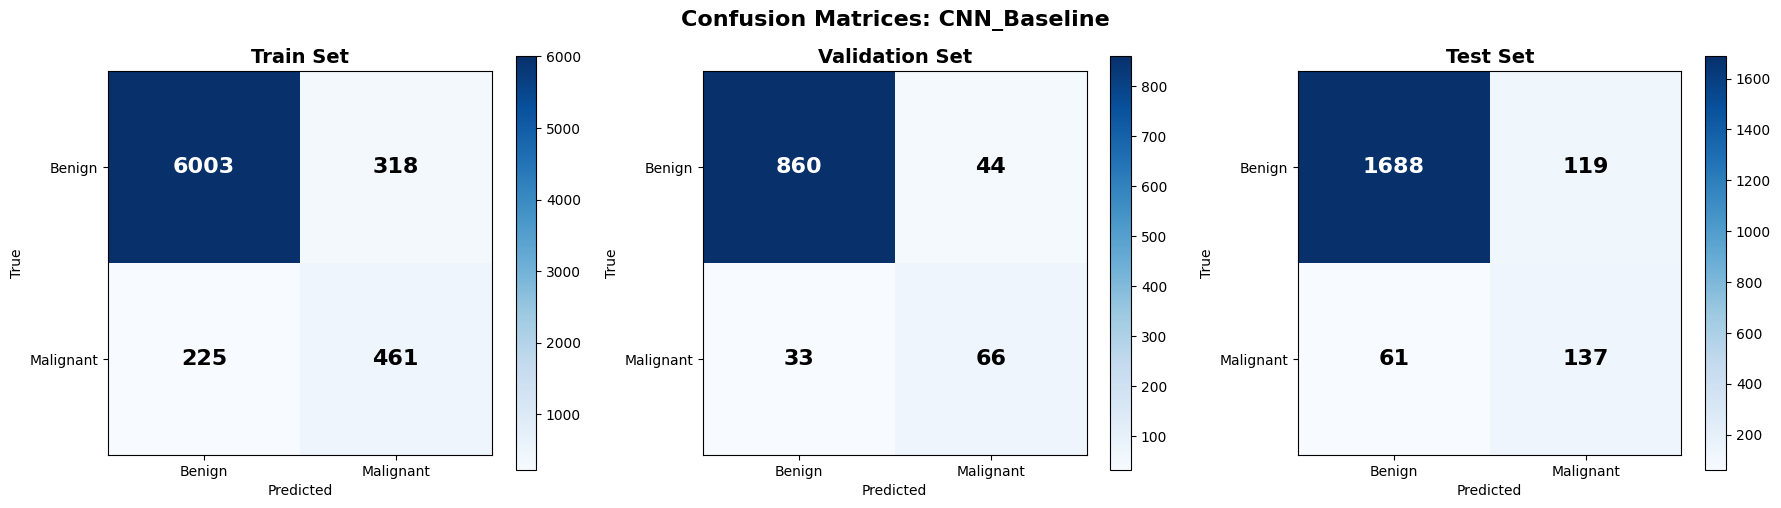


💾 Model saved: saved_models/CNN_Baseline.h5
☁️  Uploaded to W&B


epoch/accuracy,▁▄▅▆▆▇▇▇▇▇▇▇▇▇███▇████▇██████
epoch/auc,▁▅▆▆▇▇▇▇▇▇███▇███████████████
epoch/epoch,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/precision,▁▄▅▆▆▇▇▇▇▇▇▇▇▇███▇████▇██████
epoch/recall,▁▄▅▆▆▇▇▇▇▇▇▇▇▇███▇████▇██████
epoch/val_accuracy,▁▁▁▁▃▆▇▇█▅▇█▇▅▇▇█▆█▄▇█▇▃▄▇▆▇▇
epoch/val_auc,▁▁▁▁▂▆▇██▅▇█▇▅▇▇█▆█▄▇██▃▄▇▆██
epoch/val_loss,▃▆█▆▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+23,...


In [10]:
# ============================================================================
# EXPERIMENT: Custom CNN - Baseline
# ============================================================================
# Start with proven baseline configuration

model = build_custom_cnn(
    filters_base=32,   # 🔧 TUNE: 16, 32, 64, 128
    depth=3,           # 🔧 TUNE: 2, 3, 4
    dropout=0.5,       # 🔧 TUNE: 0.3, 0.5, 0.7
    dense_units=512    # 🔧 TUNE: 256, 512, 1024
)

result_cnn_1 = train_experiment(model, {
    'name': 'CNN_Baseline',
    'architecture': 'custom_cnn',
    'filters_base': 32,
    'depth': 3,
    'dropout': 0.5,
    'dense_units': 512,
    'learning_rate': 0.001,  # 🔧 TUNE: 0.0001 (slow), 0.001 (good), 0.01 (fast)
    'batch_size': 64,        # 🔧 TUNE: 32, 64, 128
    'epochs': 30
})


EXPERIMENT: CNN_Wider
  architecture: custom_cnn
  filters_base: 64
  depth: 3
  dropout: 0.5
  dense_units: 512
  learning_rate: 0.001
  batch_size: 64
  epochs: 30




Training (max 30 epochs)...

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6091 - auc: 0.6445 - loss: 0.9703 - precision: 0.6091 - recall: 0.6091
Epoch 1: val_recall improved from -inf to 0.09870, saving model to saved_models/CNN_Wider.h5


110/110 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - accuracy: 0.6094 - auc: 0.6450 - loss: 0.9689 - precision: 0.6094 - recall: 0.6094 - val_accuracy: 0.0987 - val_auc: 0.0987 - val_loss: 25.5428 - val_precision: 0.0987 - val_recall: 0.0987
Epoch 2/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7429 - auc: 0.8214 - loss: 0.5345 - precision: 0.7429 - recall: 0.7429
Epoch 2: val_recall did not improve from 0.09870
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.7430 - auc: 0.8215 - loss: 0.5344 - precision: 0.7430 - recall: 0.7430 - val_accuracy: 0.0987 - val_auc: 0.0987 - val_loss: 34.3276 - val_precision: 0.0987 - val_recall: 0.0987
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7519 - auc: 0.8436 - loss: 0.4598 - precision: 0.7519 - recall: 0.7519
Epoch 3: val_recall did not improve from 0.09870
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.7520 - auc: 0.8437 - loss: 0.4597 - precision: 0.7520 - recall: 0.7520 - val_accuracy: 0.0987 - val_au

...

110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.7854 - auc: 0.8767 - loss: 0.4040 - precision: 0.7854 - recall: 0.7854 - val_accuracy: 0.6899 - val_auc: 0.6829 - val_loss: 1.1461 - val_precision: 0.6899 - val_recall: 0.6899
Epoch 6/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8193 - auc: 0.9047 - loss: 0.3819 - precision: 0.8193 - recall: 0.8193
Epoch 6: val_recall improved from 0.68993 to 0.85344, saving model to saved_models/CNN_Wider.h5


110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8194 - auc: 0.9047 - loss: 0.3819 - precision: 0.8194 - recall: 0.8194 - val_accuracy: 0.8534 - val_auc: 0.9257 - val_loss: 0.3561 - val_precision: 0.8534 - val_recall: 0.8534
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8008 - auc: 0.8867 - loss: 0.3887 - precision: 0.8008 - recall: 0.8008
Epoch 7: val_recall did not improve from 0.85344
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8009 - auc: 0.8868 - loss: 0.3887 - precision: 0.8009 - recall: 0.8009 - val_accuracy: 0.8086 - val_auc: 0.8634 - val_loss: 0.5104 - val_precision: 0.8086 - val_recall: 0.8086
Epoch 8/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8241 - auc: 0.9055 - loss: 0.3633 - precision: 0.8241 - recall: 0.8241
Epoch 8: val_recall did not improve from 0.85344
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8241 - auc: 0.9055 - loss: 0.3633 - precision: 0.8241 - recall: 0.8241 - val_accuracy: 0.7278 - val_auc: 0

110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.8419 - auc: 0.9248 - loss: 0.3298 - precision: 0.8419 - recall: 0.8419 - val_accuracy: 0.8734 - val_auc: 0.9324 - val_loss: 0.3800 - val_precision: 0.8734 - val_recall: 0.8734
Epoch 16/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8260 - auc: 0.9139 - loss: 0.3532 - precision: 0.8260 - recall: 0.8260
Epoch 16: val_recall improved from 0.87338 to 0.90828, saving model to saved_models/CNN_Wider.h5


110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8261 - auc: 0.9140 - loss: 0.3530 - precision: 0.8261 - recall: 0.8261 - val_accuracy: 0.9083 - val_auc: 0.9701 - val_loss: 0.2211 - val_precision: 0.9083 - val_recall: 0.9083
Epoch 17/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8380 - auc: 0.9223 - loss: 0.3430 - precision: 0.8380 - recall: 0.8380
Epoch 17: val_recall did not improve from 0.90828
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8379 - auc: 0.9223 - loss: 0.3432 - precision: 0.8379 - recall: 0.8379 - val_accuracy: 0.5533 - val_auc: 0.5908 - val_loss: 0.7436 - val_precision: 0.5533 - val_recall: 0.5533
Epoch 18/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8256 - auc: 0.9146 - loss: 0.3450 - precision: 0.8256 - recall: 0.8256
Epoch 18: val_recall did not improve from 0.90828
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8256 - auc: 0.9146 - loss: 0.3451 - precision: 0.8256 - recall: 0.8256 - val_accuracy: 0.8385 - val_au

110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8485 - auc: 0.9335 - loss: 0.3186 - precision: 0.8485 - recall: 0.8485 - val_accuracy: 0.9192 - val_auc: 0.9836 - val_loss: 0.1656 - val_precision: 0.9192 - val_recall: 0.9192
Epoch 26/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8293 - auc: 0.9163 - loss: 0.3586 - precision: 0.8293 - recall: 0.8293
Epoch 26: val_recall did not improve from 0.91924
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8295 - auc: 0.9165 - loss: 0.3579 - precision: 0.8295 - recall: 0.8295 - val_accuracy: 0.8624 - val_auc: 0.9449 - val_loss: 0.3142 - val_precision: 0.8624 - val_recall: 0.8624
Epoch 27/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8610 - auc: 0.9434 - loss: 0.2937 - precision: 0.8610 - recall: 0.8610
Epoch 27: val_recall did not improve from 0.91924
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8607 - auc: 0.9433 - loss: 0.2942 - precision: 0.8607 - recall: 0.8607 - val_accuracy: 0.9153 - val_au

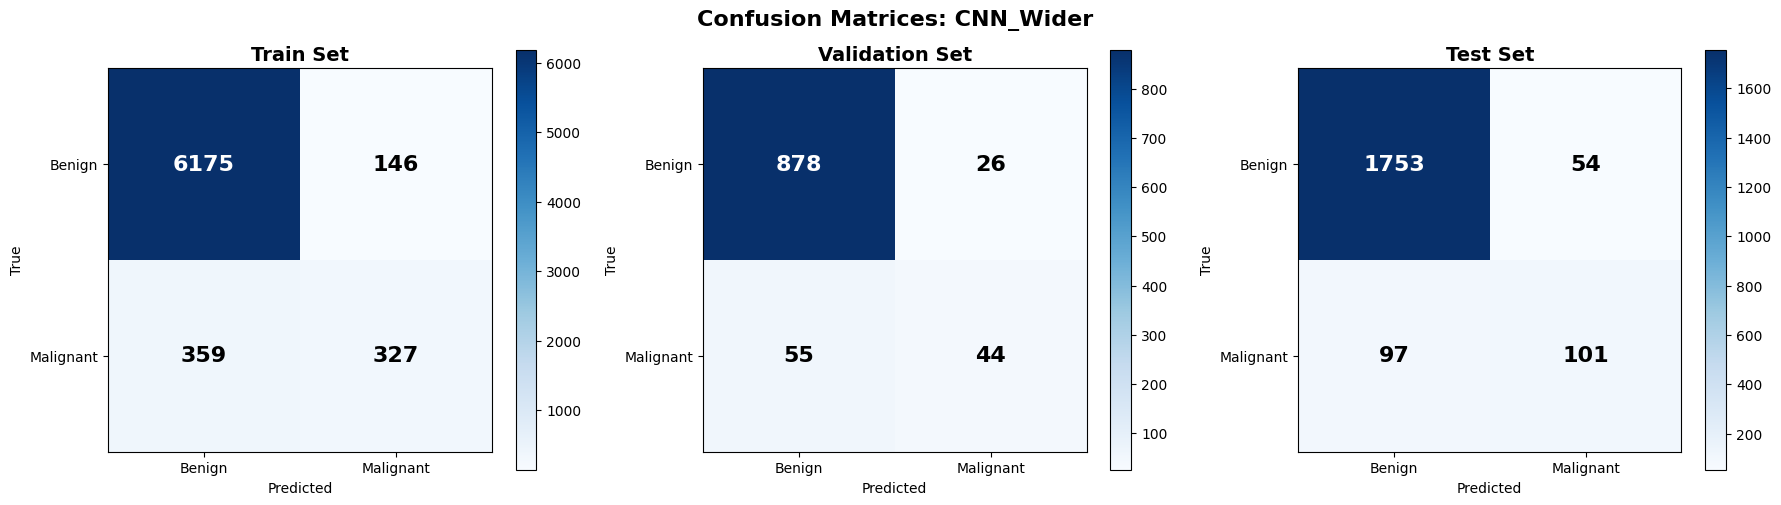


💾 Model saved: saved_models/CNN_Wider.h5
☁️  Uploaded to W&B


epoch/accuracy,▁▅▅▆▆▇▇▇▇▇▇▇▇▇█▇▇▇▇▇▇▇█▇██████
epoch/auc,▁▅▆▇▇▇▇▇▇█▇▇▇████▇▇███████████
epoch/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▂▂▂▂▂▂▂▂▂▂▁▁▁▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch/precision,▁▅▅▆▆▇▇▇▇▇▇▇▇▇█▇▇▇▇▇▇▇█▇██████
epoch/recall,▁▅▅▆▆▇▇▇▇▇▇▇▇▇█▇▇▇▇▇▇▇█▇██████
epoch/val_accuracy,▁▁▁▁▆▇▇▆▇▄▆▇▆▅██▅▇█▇▇▇█▇██████
epoch/val_auc,▁▁▁▁▆█▇▆▇▃▆█▆▅██▅██▇▇█████████
epoch/val_loss,▅▆█▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+23,...


In [11]:
# ============================================================================
# EXPERIMENT: Custom CNN - Your Configuration
# ============================================================================
# Copy this cell and modify parameters based on W&B results

model = build_custom_cnn(
    filters_base=64,   # Changed based on experiment 1
    depth=3,
    dropout=0.5,
    dense_units=512
)

result_cnn_2 = train_experiment(model, {
    'name': 'CNN_Wider',  # Give it a descriptive name
    'architecture': 'custom_cnn',
    'filters_base': 64,
    'depth': 3,
    'dropout': 0.5,
    'dense_units': 512,
    'learning_rate': 0.001,
    'batch_size': 64,
    'epochs': 30
})


EXPERIMENT: CNN_HighLR
  architecture: custom_cnn
  filters_base: 32
  depth: 3
  dropout: 0.5
  dense_units: 512
  learning_rate: 0.01
  batch_size: 64
  epochs: 30




Training (max 30 epochs)...

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6333 - auc: 0.6733 - loss: 1.2447 - precision: 0.6333 - recall: 0.6333
Epoch 1: val_recall improved from -inf to 0.10469, saving model to saved_models/CNN_HighLR.h5


110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - accuracy: 0.6342 - auc: 0.6744 - loss: 1.2391 - precision: 0.6342 - recall: 0.6342 - val_accuracy: 0.1047 - val_auc: 0.1049 - val_loss: 1.7985 - val_precision: 0.1047 - val_recall: 0.1047
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7015 - auc: 0.7687 - loss: 0.7228 - precision: 0.7015 - recall: 0.7015
Epoch 2: val_recall improved from 0.10469 to 0.90030, saving model to saved_models/CNN_HighLR.h5


110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.7017 - auc: 0.7689 - loss: 0.7222 - precision: 0.7017 - recall: 0.7017 - val_accuracy: 0.9003 - val_auc: 0.9297 - val_loss: 0.3138 - val_precision: 0.9003 - val_recall: 0.9003
Epoch 3/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7401 - auc: 0.8249 - loss: 0.5732 - precision: 0.7401 - recall: 0.7401
Epoch 3: val_recall did not improve from 0.90030
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7400 - auc: 0.8250 - loss: 0.5725 - precision: 0.7400 - recall: 0.7400 - val_accuracy: 0.5753 - val_auc: 0.5618 - val_loss: 1.0197 - val_precision: 0.5753 - val_recall: 0.5753
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7647 - auc: 0.8505 - loss: 0.5858 - precision: 0.7647 - recall: 0.7647
Epoch 4: val_recall did not improve from 0.90030
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7646 - auc: 0.8504 - loss: 0.5854 - precision: 0.7646 - recall: 0.7646 - val_accuracy: 0.8824 - val_auc: 0

110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.7780 - auc: 0.8785 - loss: 0.4203 - precision: 0.7780 - recall: 0.7780 - val_accuracy: 0.9063 - val_auc: 0.9714 - val_loss: 0.2198 - val_precision: 0.9063 - val_recall: 0.9063
Epoch 10/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8220 - auc: 0.9118 - loss: 0.3701 - precision: 0.8220 - recall: 0.8220
Epoch 10: val_recall did not improve from 0.90628
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8219 - auc: 0.9117 - loss: 0.3703 - precision: 0.8219 - recall: 0.8219 - val_accuracy: 0.8096 - val_auc: 0.9177 - val_loss: 0.3816 - val_precision: 0.8096 - val_recall: 0.8096
Epoch 11/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8072 - auc: 0.8999 - loss: 0.3929 - precision: 0.8072 - recall: 0.8072
Epoch 11: val_recall did not improve from 0.90628
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8073 - auc: 0.9000 - loss: 0.3927 - precision: 0.8073 - recall: 0.8073 - val_accuracy: 0.8853 - val_au

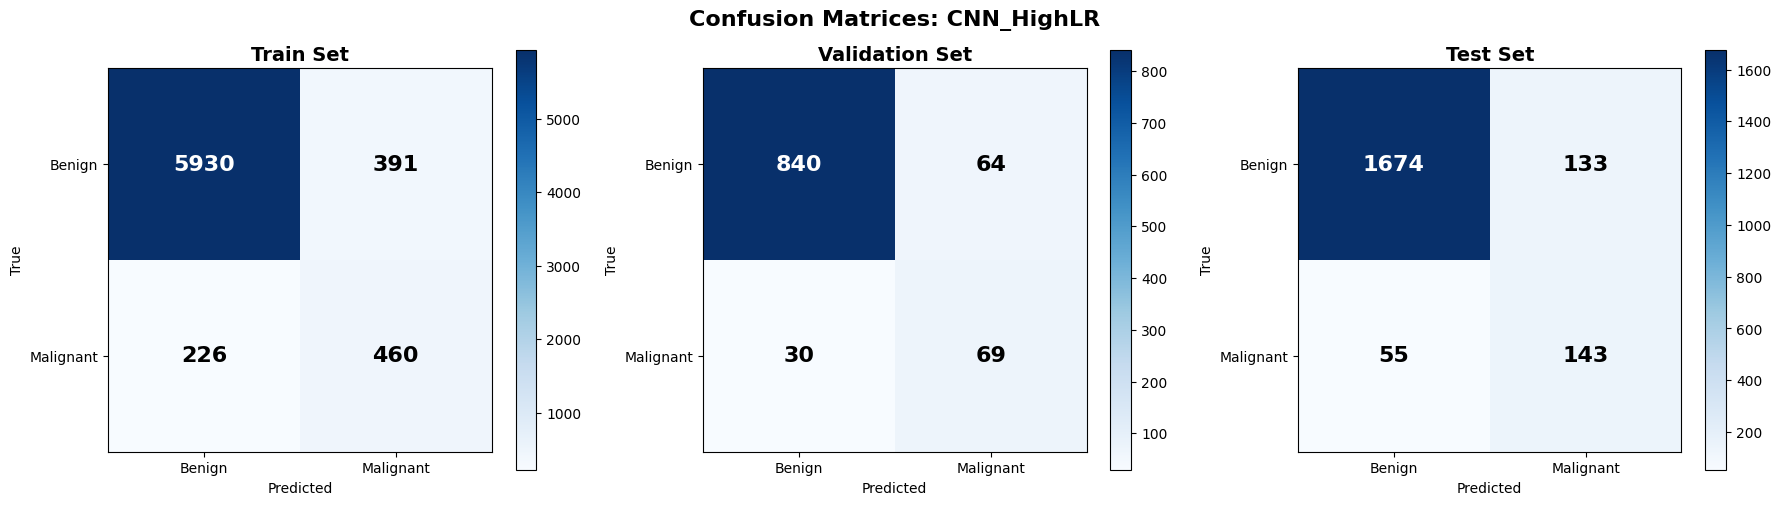


💾 Model saved: saved_models/CNN_HighLR.h5
☁️  Uploaded to W&B


epoch/accuracy,▁▃▄▄▅▆▆▆▆█▇███▇█▇██
epoch/auc,▁▃▅▅▆▇▆▇▇▇▇████████
epoch/epoch,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch/precision,▁▃▄▄▅▆▆▆▆█▇███▇█▇██
epoch/recall,▁▃▄▄▅▆▆▆▆█▇███▇█▇██
epoch/val_accuracy,▁█▅█▇▇▂▇█▇██▇▇██▆██
epoch/val_auc,▁█▅█▇▇▂▇████▇███▆██
epoch/val_loss,▆▁▃▁▂▃█▂▁▂▁▁▂▂▁▁▂▁▁
+23,...


In [12]:
# ============================================================================
# EXPERIMENT: Custom CNN - Learning Rate Tuning
# ============================================================================
# Test different learning rates to find optimal convergence speed
#
# Learning rate effects:
#   Too low (0.0001):  Slow convergence, may need 50+ epochs
#   Just right (0.001): Good balance, converges in 15-20 epochs
#   Too high (0.01):    Fast but unstable, may oscillate or diverge

model = build_custom_cnn(
    filters_base=32,
    depth=3,
    dropout=0.5,
    dense_units=512
)

result_cnn_3 = train_experiment(model, {
    'name': 'CNN_HighLR',
    'architecture': 'custom_cnn',
    'filters_base': 32,
    'depth': 3,
    'dropout': 0.5,
    'dense_units': 512,
    'learning_rate': 0.01,   # 🔧 Try: 0.01, then compare to 0.001 in W&B
    'batch_size': 64,
    'epochs': 30
})

### Experiment Group 2: ResNet50 Fine-Tuned

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  RESNET50 - all_layers
  Total params: 24,113,794
  Trainable params: 24,060,162 (-78.3%)

EXPERIMENT: ResNet50_FullFineTune
  architecture: resnet50
  dropout: 0.5
  unfreeze_layers: all
  dense_units: 256
  learning_rate: 0.0001
  batch_size: 32
  epochs: 30



/tmp/ipython-input-1866804078.py:63: RuntimeWarning: overflow encountered in scalar multiply
  print(f"  Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")



Training (max 30 epochs)...

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.5311 - auc: 0.5799 - loss: 0.7587 - precision: 0.5311 - recall: 0.5311
Epoch 1: val_recall improved from -inf to 0.90130, saving model to saved_models/ResNet50_FullFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 106s 228ms/step - accuracy: 0.5313 - auc: 0.5801 - loss: 0.7583 - precision: 0.5313 - recall: 0.5313 - val_accuracy: 0.9013 - val_auc: 0.8963 - val_loss: 0.6086 - val_precision: 0.9013 - val_recall: 0.9013
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6659 - auc: 0.7212 - loss: 0.5327 - precision: 0.6659 - recall: 0.6659
Epoch 2: val_recall did not improve from 0.90130
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.6661 - auc: 0.7213 - loss: 0.5326 - precision: 0.6661 - recall: 0.6661 - val_accuracy: 0.9013 - val_auc: 0.8988 - val_loss: 1.0699 - val_precision: 0.9013 - val_recall: 0.9013
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7639 - auc: 0.8194 - loss: 0.4018 - precision: 0.7639 - recall: 0.7639
Epoch 3: val_recall did not improve from 0.90130
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.7640 - auc: 0.8195 - loss: 0.4018 - precision: 0.7640 - recall: 0.7640 - val_accuracy: 0.7607 - val_a

219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.8197 - auc: 0.8650 - loss: 0.3666 - precision: 0.8197 - recall: 0.8197 - val_accuracy: 0.9023 - val_auc: 0.9664 - val_loss: 0.3141 - val_precision: 0.9023 - val_recall: 0.9023
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8453 - auc: 0.8938 - loss: 0.3482 - precision: 0.8453 - recall: 0.8453
Epoch 5: val_recall improved from 0.90229 to 0.92921, saving model to saved_models/ResNet50_FullFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.8453 - auc: 0.8938 - loss: 0.3482 - precision: 0.8453 - recall: 0.8453 - val_accuracy: 0.9292 - val_auc: 0.9791 - val_loss: 0.2438 - val_precision: 0.9292 - val_recall: 0.9292
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8536 - auc: 0.9089 - loss: 0.3127 - precision: 0.8536 - recall: 0.8536
Epoch 6: val_recall did not improve from 0.92921
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.8536 - auc: 0.9089 - loss: 0.3127 - precision: 0.8536 - recall: 0.8536 - val_accuracy: 0.8843 - val_auc: 0.9349 - val_loss: 0.3251 - val_precision: 0.8843 - val_recall: 0.8843
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8575 - auc: 0.9146 - loss: 0.3022 - precision: 0.8575 - recall: 0.8575
Epoch 7: val_recall did not improve from 0.92921
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.8575 - auc: 0.9146 - loss: 0.3022 - precision: 0.8575 - recall: 0.8575 - val_accuracy: 0.9003 - val_auc

219/219 ━━━━━━━━━━━━━━━━━━━━ 30s 135ms/step - accuracy: 0.8665 - auc: 0.9245 - loss: 0.2898 - precision: 0.8665 - recall: 0.8665 - val_accuracy: 0.9342 - val_auc: 0.9835 - val_loss: 0.1694 - val_precision: 0.9342 - val_recall: 0.9342
Epoch 9/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8715 - auc: 0.9248 - loss: 0.2715 - precision: 0.8715 - recall: 0.8715
Epoch 9: val_recall did not improve from 0.93420
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.8715 - auc: 0.9248 - loss: 0.2716 - precision: 0.8715 - recall: 0.8715 - val_accuracy: 0.8833 - val_auc: 0.9351 - val_loss: 0.3210 - val_precision: 0.8833 - val_recall: 0.8833
Epoch 10/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8695 - auc: 0.9307 - loss: 0.2914 - precision: 0.8695 - recall: 0.8695
Epoch 10: val_recall did not improve from 0.93420
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.8696 - auc: 0.9307 - loss: 0.2914 - precision: 0.8696 - recall: 0.8696 - val_accuracy: 0.8614 - val_

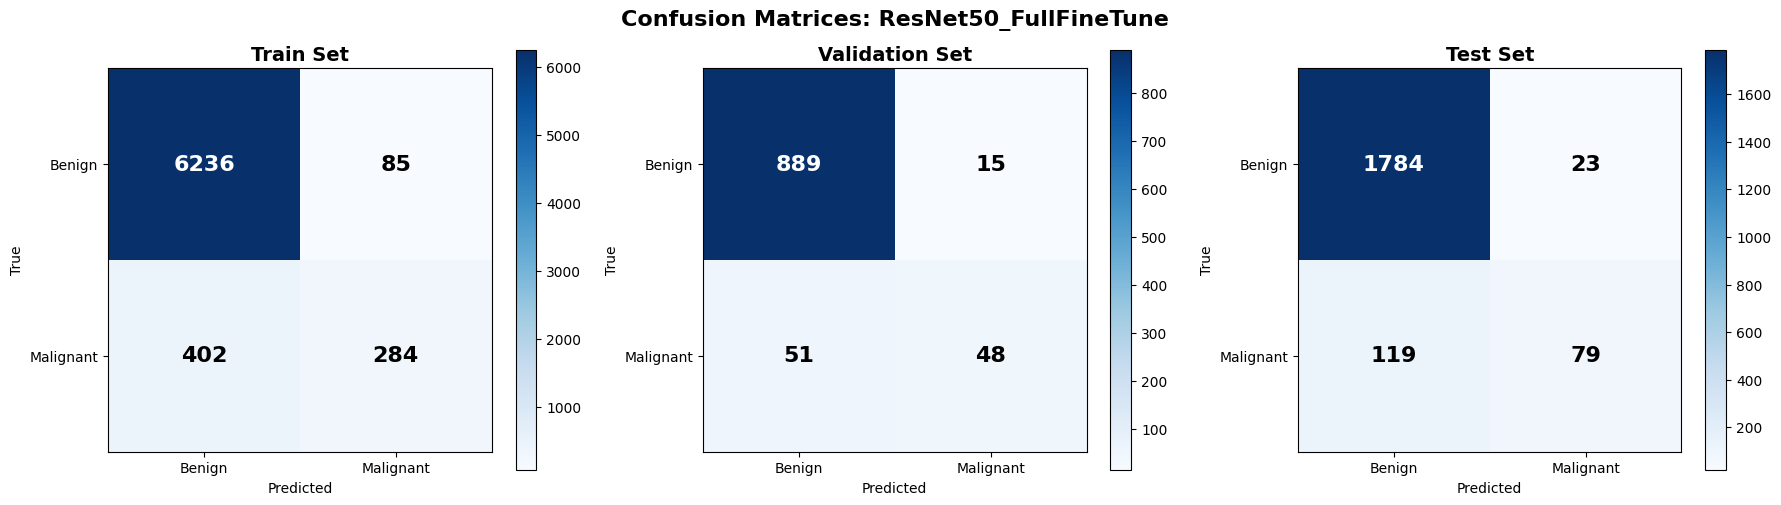


💾 Model saved: saved_models/ResNet50_FullFineTune.h5
☁️  Uploaded to W&B


epoch/accuracy,▁▃▅▆▇▇▇▇▇█████████
epoch/auc,▁▄▅▆▇▇▇▇▇█████████
epoch/epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▃▃▂▂▂▂▂▁▂▁▁▁▁▁▁
epoch/precision,▁▃▅▆▇▇▇▇▇█████████
epoch/recall,▁▃▅▆▇▇▇▇▇█████████
epoch/val_accuracy,▇▇▁▇█▆▇█▆▅▆▅▂▄▆▄▆▇
epoch/val_auc,▄▄▁▇█▆▆█▆▅▇▆▂▄▆▅▆▇
epoch/val_loss,▄█▄▂▂▂▂▁▂▃▂▂▄▃▂▃▂▂
+23,...


In [13]:
# ============================================================================
# EXPERIMENT: ResNet50 - Full Fine-Tuning
# ============================================================================

model = build_transfer_model(
    base_name='resnet50',
    dropout=0.5,           # 🔧 TUNE: 0.3, 0.5, 0.7
    unfreeze_layers=None,  # 🔧 TUNE: None (all), 10, 20, 50
    dense_units=256        # 🔧 TUNE: 128, 256, 512
)

result_resnet_1 = train_experiment(model, {
    'name': 'ResNet50_FullFineTune',
    'architecture': 'resnet50',
    'dropout': 0.5,
    'unfreeze_layers': 'all',
    'dense_units': 256,
    'learning_rate': 0.0001,  # 🔧 TUNE: 0.00001, 0.0001, 0.001 (lower for fine-tuning!)
    'batch_size': 32,         # 🔧 TUNE: 16, 32 (smaller for big models)
    'epochs': 30
})


  RESNET50 - last_20_layers
  Total params: 24,113,794
  Trainable params: 8,407,810 (34.9%)

EXPERIMENT: ResNet50_PartialFineTune
  architecture: resnet50
  dropout: 0.5
  unfreeze_layers: 20
  dense_units: 256
  learning_rate: 0.0001
  batch_size: 32
  epochs: 30




Training (max 30 epochs)...

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5030 - auc: 0.5284 - loss: 0.8553 - precision: 0.5030 - recall: 0.5030
Epoch 1: val_recall improved from -inf to 0.53938, saving model to saved_models/ResNet50_PartialFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.5031 - auc: 0.5287 - loss: 0.8548 - precision: 0.5031 - recall: 0.5031 - val_accuracy: 0.5394 - val_auc: 0.5312 - val_loss: 0.6945 - val_precision: 0.5394 - val_recall: 0.5394
Epoch 2/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5727 - auc: 0.6170 - loss: 0.7247 - precision: 0.5727 - recall: 0.5727
Epoch 2: val_recall did not improve from 0.53938
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.5729 - auc: 0.6172 - loss: 0.7245 - precision: 0.5729 - recall: 0.5729 - val_accuracy: 0.1067 - val_auc: 0.1537 - val_loss: 0.9552 - val_precision: 0.1067 - val_recall: 0.1067
Epoch 3/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6402 - auc: 0.6928 - loss: 0.6680 - precision: 0.6402 - recall: 0.6402
Epoch 3: val_recall did not improve from 0.53938
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.6401 - auc: 0.6928 - loss: 0.6678 - precision: 0.6401 - recall: 0.6401 - val_accuracy: 0.3639 - val_auc

219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - accuracy: 0.6578 - auc: 0.7257 - loss: 0.5950 - precision: 0.6578 - recall: 0.6578 - val_accuracy: 0.8524 - val_auc: 0.9234 - val_loss: 0.3685 - val_precision: 0.8524 - val_recall: 0.8524
Epoch 5/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6882 - auc: 0.7678 - loss: 0.5640 - precision: 0.6882 - recall: 0.6882
Epoch 5: val_recall did not improve from 0.85244
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.6882 - auc: 0.7678 - loss: 0.5644 - precision: 0.6882 - recall: 0.6882 - val_accuracy: 0.5234 - val_auc: 0.5783 - val_loss: 0.7351 - val_precision: 0.5234 - val_recall: 0.5234
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6759 - auc: 0.7520 - loss: 0.6093 - precision: 0.6759 - recall: 0.6759
Epoch 6: val_recall did not improve from 0.85244
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.6759 - auc: 0.7520 - loss: 0.6091 - precision: 0.6759 - recall: 0.6759 - val_accuracy: 0.6690 - val_auc:

219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.7102 - auc: 0.7839 - loss: 0.5671 - precision: 0.7102 - recall: 0.7102 - val_accuracy: 0.9063 - val_auc: 0.9614 - val_loss: 0.2746 - val_precision: 0.9063 - val_recall: 0.9063
Epoch 9/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7315 - auc: 0.8081 - loss: 0.5301 - precision: 0.7315 - recall: 0.7315
Epoch 9: val_recall did not improve from 0.90628
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.7315 - auc: 0.8081 - loss: 0.5302 - precision: 0.7315 - recall: 0.7315 - val_accuracy: 0.7856 - val_auc: 0.8587 - val_loss: 0.4641 - val_precision: 0.7856 - val_recall: 0.7856
Epoch 10/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7468 - auc: 0.8197 - loss: 0.5098 - precision: 0.7468 - recall: 0.7468
Epoch 10: val_recall did not improve from 0.90628
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.7468 - auc: 0.8197 - loss: 0.5099 - precision: 0.7468 - recall: 0.7468 - val_accuracy: 0.9053 - val_a

219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.7505 - auc: 0.8350 - loss: 0.4907 - precision: 0.7505 - recall: 0.7505 - val_accuracy: 0.9093 - val_auc: 0.9670 - val_loss: 0.2568 - val_precision: 0.9093 - val_recall: 0.9093
Epoch 16/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7367 - auc: 0.8289 - loss: 0.4862 - precision: 0.7367 - recall: 0.7367
Epoch 16: val_recall did not improve from 0.90927
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.7367 - auc: 0.8289 - loss: 0.4861 - precision: 0.7367 - recall: 0.7367 - val_accuracy: 0.7697 - val_auc: 0.8647 - val_loss: 0.4820 - val_precision: 0.7697 - val_recall: 0.7697
Epoch 17/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7624 - auc: 0.8372 - loss: 0.4798 - precision: 0.7624 - recall: 0.7624
Epoch 17: val_recall did not improve from 0.90927
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.7624 - auc: 0.8372 - loss: 0.4800 - precision: 0.7624 - recall: 0.7624 - val_accuracy: 0.8784 - val_

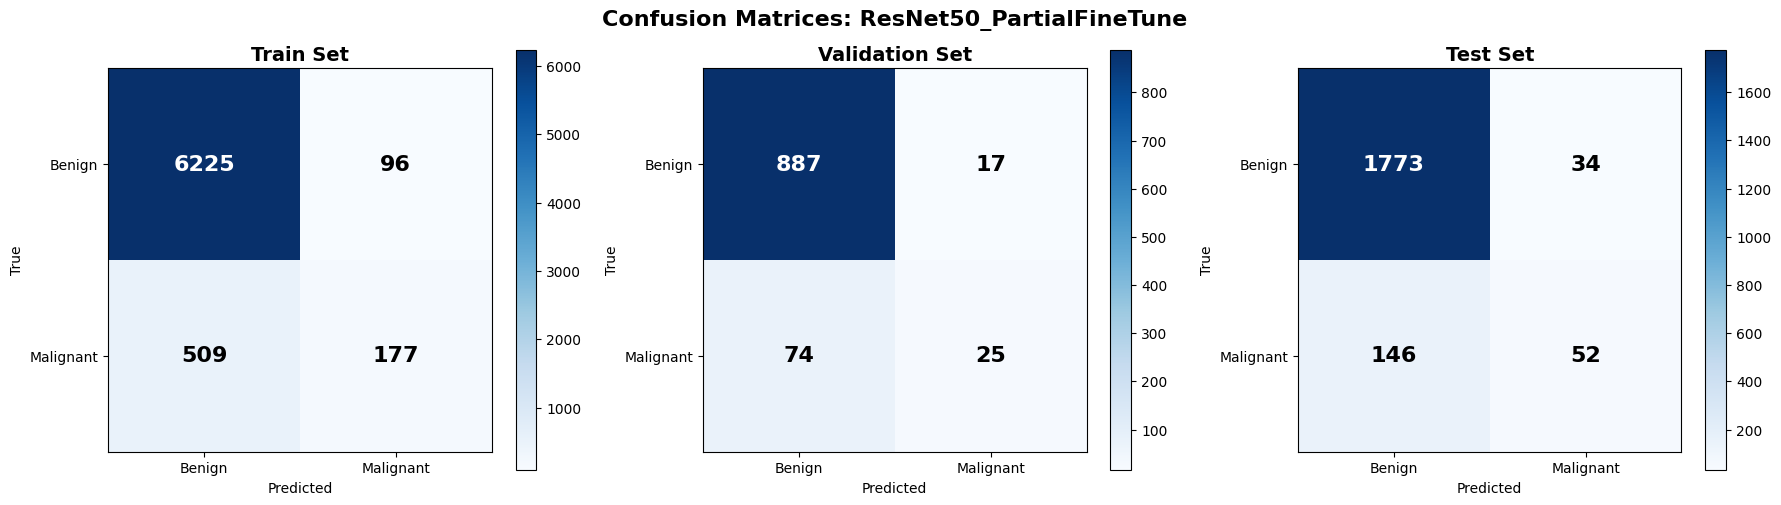


💾 Model saved: saved_models/ResNet50_PartialFineTune.h5
☁️  Uploaded to W&B


epoch/accuracy,▁▃▄▅▆▅▆▇▇▇▇▇▇▇▇▇▇▇▇██████
epoch/auc,▁▃▄▅▆▆▆▇▇▇▇▇▇▇███████████
epoch/epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▃▃▃▃▂▂▃▂▂▂▁▂▂▂▁▂▂▁▁▁
epoch/precision,▁▃▄▅▆▅▆▇▇▇▇▇▇▇▇▇▇▇▇██████
epoch/recall,▁▃▄▅▆▅▆▇▇▇▇▇▇▇▇▇▇▇▇██████
epoch/val_accuracy,▅▁▃█▅▆▄█▇██████▇███▆█▆███
epoch/val_auc,▄▁▃█▅▆▄█▇██████▇███▆█▆███
epoch/val_loss,▅█▇▂▆▄█▁▃▁▁▁▂▁▁▃▂▁▁▅▁▅▂▂▂
+23,...


In [14]:
# ============================================================================
# EXPERIMENT: ResNet50 - Partial Fine-Tuning (Last N Layers)
# ============================================================================

model = build_transfer_model(
    base_name='resnet50',
    dropout=0.5,
    unfreeze_layers=20,    # Only train last 20 layers
    dense_units=256
)

result_resnet_2 = train_experiment(model, {
    'name': 'ResNet50_PartialFineTune',
    'architecture': 'resnet50',
    'dropout': 0.5,
    'unfreeze_layers': 20,
    'dense_units': 256,
    'learning_rate': 0.0001,
    'batch_size': 32,
    'epochs': 30
})

### Experiment Group 3: VGG16 Fine-Tuned

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  VGG16 - all_layers
  Total params: 14,847,554
  Trainable params: 14,847,042 (100.0%)

EXPERIMENT: VGG16_FullFineTune
  architecture: vgg16
  dropout: 0.5
  unfreeze_layers: all
  dense_units: 256
  learning_rate: 0.0001
  batch_size: 32
  epochs: 30




Training (max 30 epochs)...

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5292 - auc: 0.5581 - loss: 0.8321 - precision: 0.5292 - recall: 0.5292
Epoch 1: val_recall improved from -inf to 0.64108, saving model to saved_models/VGG16_FullFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 62s 217ms/step - accuracy: 0.5292 - auc: 0.5582 - loss: 0.8316 - precision: 0.5292 - recall: 0.5292 - val_accuracy: 0.6411 - val_auc: 0.7536 - val_loss: 0.6625 - val_precision: 0.6411 - val_recall: 0.6411
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5802 - auc: 0.6542 - loss: 0.5778 - precision: 0.5802 - recall: 0.5802
Epoch 2: val_recall did not improve from 0.64108
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.5803 - auc: 0.6543 - loss: 0.5777 - precision: 0.5803 - recall: 0.5803 - val_accuracy: 0.3031 - val_auc: 0.2869 - val_loss: 1.2290 - val_precision: 0.3031 - val_recall: 0.3031
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6643 - auc: 0.7497 - loss: 0.4981 - precision: 0.6643 - recall: 0.6643
Epoch 3: val_recall did not improve from 0.64108
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.6644 - auc: 0.7498 - loss: 0.4979 - precision: 0.6644 - recall: 0.6644 - val_accuracy: 0.2403 - val_au

219/219 ━━━━━━━━━━━━━━━━━━━━ 32s 145ms/step - accuracy: 0.6928 - auc: 0.7805 - loss: 0.4985 - precision: 0.6928 - recall: 0.6928 - val_accuracy: 0.7667 - val_auc: 0.8746 - val_loss: 0.4449 - val_precision: 0.7667 - val_recall: 0.7667
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7435 - auc: 0.8317 - loss: 0.4403 - precision: 0.7435 - recall: 0.7435
Epoch 5: val_recall improved from 0.76670 to 0.89332, saving model to saved_models/VGG16_FullFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 130ms/step - accuracy: 0.7435 - auc: 0.8317 - loss: 0.4402 - precision: 0.7435 - recall: 0.7435 - val_accuracy: 0.8933 - val_auc: 0.9720 - val_loss: 0.2601 - val_precision: 0.8933 - val_recall: 0.8933
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7689 - auc: 0.8628 - loss: 0.4106 - precision: 0.7689 - recall: 0.7689
Epoch 6: val_recall did not improve from 0.89332
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.7689 - auc: 0.8628 - loss: 0.4106 - precision: 0.7689 - recall: 0.7689 - val_accuracy: 0.7986 - val_auc: 0.8879 - val_loss: 0.4247 - val_precision: 0.7986 - val_recall: 0.7986
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7927 - auc: 0.8794 - loss: 0.3746 - precision: 0.7927 - recall: 0.7927
Epoch 7: val_recall did not improve from 0.89332
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.7927 - auc: 0.8794 - loss: 0.3745 - precision: 0.7927 - recall: 0.7927 - val_accuracy: 0.2333 - val_au

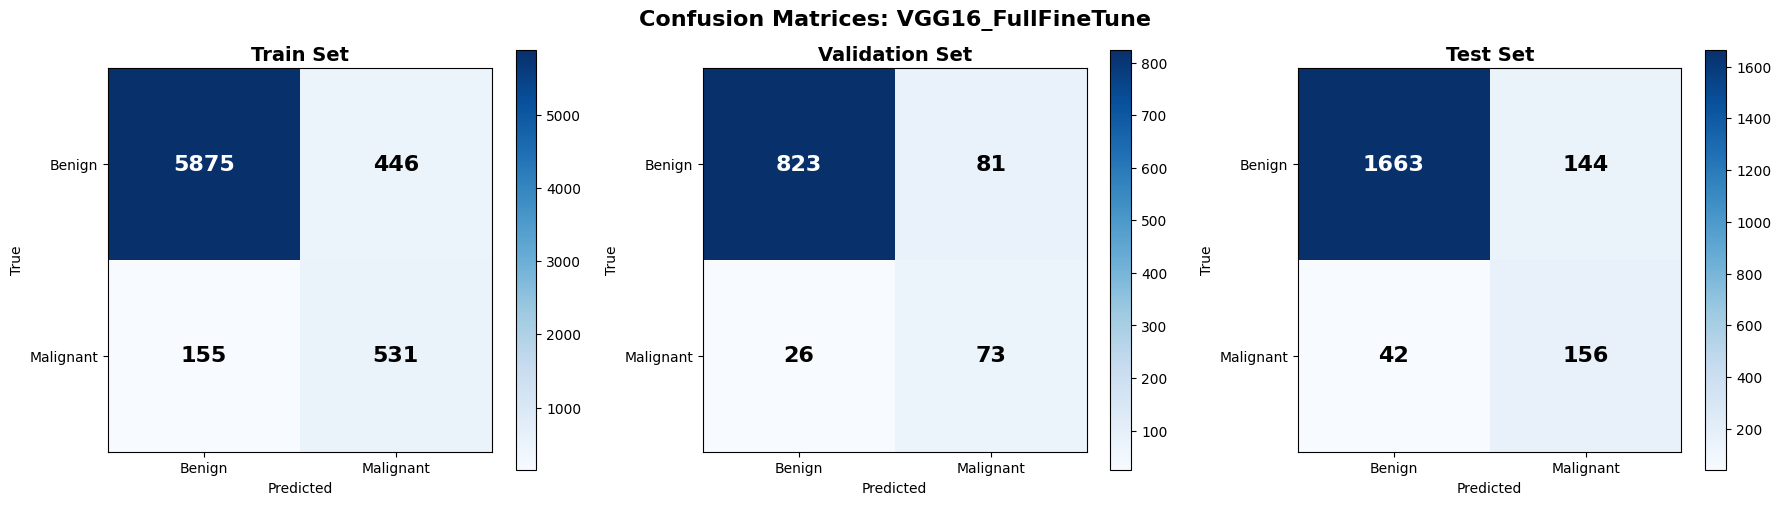


💾 Model saved: saved_models/VGG16_FullFineTune.h5
☁️  Uploaded to W&B


epoch/accuracy,▁▃▄▅▆▆▇▇▇██████
epoch/auc,▁▃▅▅▆▇▇▇▇██████
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▄▃▃▂▂▂▂▁▁▁▁▁
epoch/precision,▁▃▄▅▆▆▇▇▇██████
epoch/recall,▁▃▄▅▆▆▇▇▇██████
epoch/val_accuracy,▅▂▁▇█▇▁▁▂▅▅▄▄▆▄
epoch/val_auc,▆▂▁▇█▇▁▁▂▅▅▄▄▆▄
epoch/val_loss,▄█▆▂▁▂█▇▇▅▄▆▅▄▅
+23,...


In [15]:
# ============================================================================
# EXPERIMENT: VGG16 - Full Fine-Tuning
# ============================================================================

model = build_transfer_model(
    base_name='vgg16',
    dropout=0.5,
    unfreeze_layers=None,  # Unfreeze all
    dense_units=256
)

result_vgg_1 = train_experiment(model, {
    'name': 'VGG16_FullFineTune',
    'architecture': 'vgg16',
    'dropout': 0.5,
    'unfreeze_layers': 'all',
    'dense_units': 256,
    'learning_rate': 0.0001,
    'batch_size': 32,
    'epochs': 30
})


  VGG16 - last_10_layers
  Total params: 14,847,554
  Trainable params: 13,111,554 (88.3%)

EXPERIMENT: VGG16_PartialFineTune
  architecture: vgg16
  dropout: 0.5
  unfreeze_layers: 10
  dense_units: 256
  learning_rate: 0.0001
  batch_size: 32
  epochs: 30




Training (max 30 epochs)...

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5240 - auc: 0.5404 - loss: 0.8548 - precision: 0.5240 - recall: 0.5240
Epoch 1: val_recall improved from -inf to 0.78465, saving model to saved_models/VGG16_PartialFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.5241 - auc: 0.5405 - loss: 0.8544 - precision: 0.5241 - recall: 0.5241 - val_accuracy: 0.7846 - val_auc: 0.9042 - val_loss: 0.3862 - val_precision: 0.7846 - val_recall: 0.7846
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5740 - auc: 0.6321 - loss: 0.6241 - precision: 0.5740 - recall: 0.5740
Epoch 2: val_recall improved from 0.78465 to 0.83549, saving model to saved_models/VGG16_PartialFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.5741 - auc: 0.6323 - loss: 0.6239 - precision: 0.5741 - recall: 0.5741 - val_accuracy: 0.8355 - val_auc: 0.9180 - val_loss: 0.3669 - val_precision: 0.8355 - val_recall: 0.8355
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6549 - auc: 0.7348 - loss: 0.5149 - precision: 0.6549 - recall: 0.6549
Epoch 3: val_recall did not improve from 0.83549
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.6549 - auc: 0.7348 - loss: 0.5148 - precision: 0.6549 - recall: 0.6549 - val_accuracy: 0.4227 - val_auc: 0.4263 - val_loss: 0.9233 - val_precision: 0.4227 - val_recall: 0.4227
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6988 - auc: 0.7862 - loss: 0.4630 - precision: 0.6988 - recall: 0.6988
Epoch 4: val_recall improved from 0.83549 to 0.90528, saving model to saved_models/VGG16_PartialFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 26s 118ms/step - accuracy: 0.6988 - auc: 0.7863 - loss: 0.4629 - precision: 0.6988 - recall: 0.6988 - val_accuracy: 0.9053 - val_auc: 0.9720 - val_loss: 0.2200 - val_precision: 0.9053 - val_recall: 0.9053
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7315 - auc: 0.8213 - loss: 0.4734 - precision: 0.7315 - recall: 0.7315
Epoch 5: val_recall did not improve from 0.90528
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 68ms/step - accuracy: 0.7315 - auc: 0.8213 - loss: 0.4733 - precision: 0.7315 - recall: 0.7315 - val_accuracy: 0.7787 - val_auc: 0.8661 - val_loss: 0.4590 - val_precision: 0.7787 - val_recall: 0.7787
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7623 - auc: 0.8518 - loss: 0.4059 - precision: 0.7623 - recall: 0.7623
Epoch 6: val_recall did not improve from 0.90528
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.7623 - auc: 0.8518 - loss: 0.4059 - precision: 0.7623 - recall: 0.7623 - val_accuracy: 0.7278 - val_au

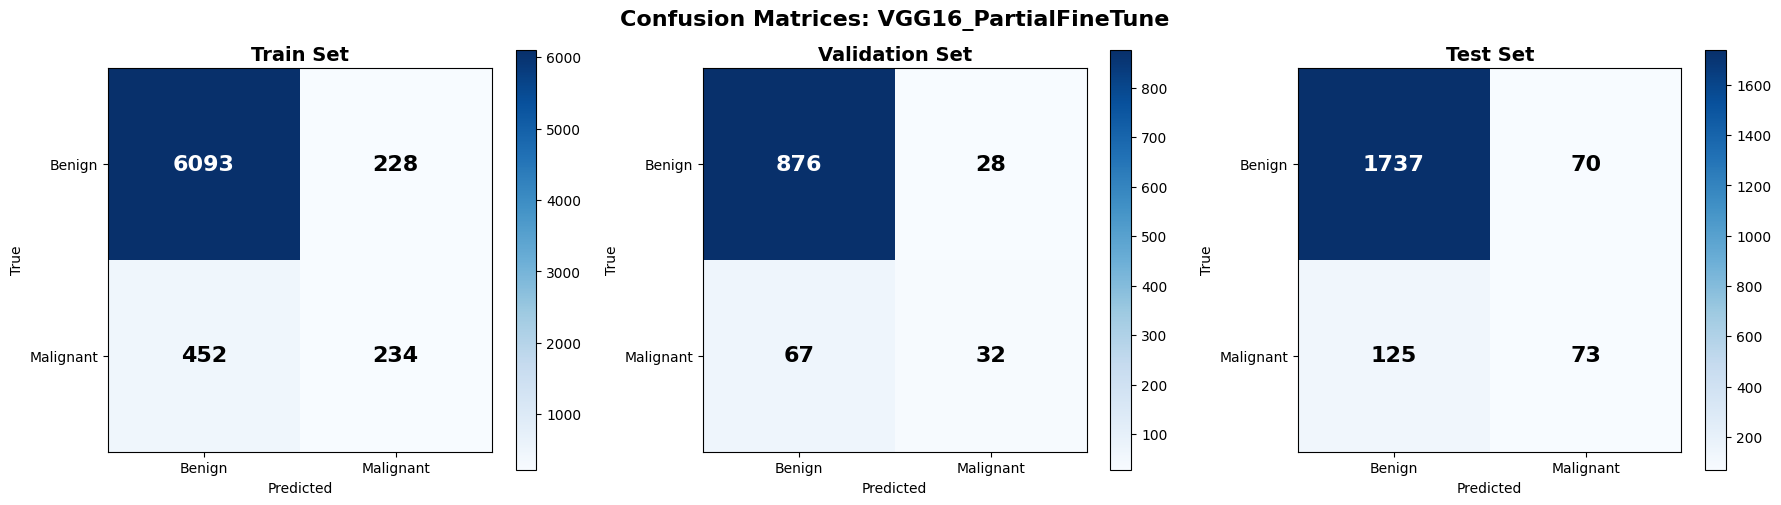


💾 Model saved: saved_models/VGG16_PartialFineTune.h5
☁️  Uploaded to W&B


epoch/accuracy,▁▂▄▅▆▆▆▇▇▇████
epoch/auc,▁▃▅▆▆▇▇▇▇█████
epoch/epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▃▃▂▃▂▂▂▁▂▁▁
epoch/precision,▁▂▄▅▆▆▆▇▇▇████
epoch/recall,▁▂▄▅▆▆▆▇▇▇████
epoch/val_accuracy,▇▇▃█▇▆▇▇▃▆▆▃▁▂
epoch/val_auc,▇█▃█▇▇▇▇▃▆▆▂▁▂
epoch/val_loss,▂▂▅▁▂▃▂▂▅▃▃▆█▆
+23,...


In [16]:
# ============================================================================
# EXPERIMENT: VGG16 - Your Configuration
# ============================================================================

model = build_transfer_model(
    base_name='vgg16',
    dropout=0.5,
    unfreeze_layers=10,  # Adjust based on results
    dense_units=256
)

result_vgg_2 = train_experiment(model, {
    'name': 'VGG16_PartialFineTune',
    'architecture': 'vgg16',
    'dropout': 0.5,
    'unfreeze_layers': 10,
    'dense_units': 256,
    'learning_rate': 0.0001,
    'batch_size': 32,
    'epochs': 30
})

### Experiment Group 4: EfficientNet Fine-Tuned

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  EFFICIENTNET - all_layers
  Total params: 4,379,045
  Trainable params: 4,336,510 (99.0%)

EXPERIMENT: EfficientNet_FullFineTune
  architecture: efficientnet
  dropout: 0.5
  unfreeze_layers: all
  dense_units: 256
  learning_rate: 0.0001
  batch_size: 32
  epochs: 30




Training (max 30 epochs)...

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.5274 - auc: 0.5568 - loss: 0.8599 - precision: 0.5274 - recall: 0.5274
Epoch 1: val_recall improved from -inf to 0.85344, saving model to saved_models/EfficientNet_FullFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 153s 329ms/step - accuracy: 0.5275 - auc: 0.5569 - loss: 0.8597 - precision: 0.5275 - recall: 0.5275 - val_accuracy: 0.8534 - val_auc: 0.8994 - val_loss: 0.5997 - val_precision: 0.8534 - val_recall: 0.8534
Epoch 2/30
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6017 - auc: 0.6538 - loss: 0.6754 - precision: 0.6017 - recall: 0.6017
Epoch 2: val_recall improved from 0.85344 to 0.89133, saving model to saved_models/EfficientNet_FullFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.6018 - auc: 0.6540 - loss: 0.6749 - precision: 0.6018 - recall: 0.6018 - val_accuracy: 0.8913 - val_auc: 0.9119 - val_loss: 0.3471 - val_precision: 0.8913 - val_recall: 0.8913
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6651 - auc: 0.7365 - loss: 0.5433 - precision: 0.6651 - recall: 0.6651
Epoch 3: val_recall did not improve from 0.89133
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.6651 - auc: 0.7366 - loss: 0.5433 - precision: 0.6651 - recall: 0.6651 - val_accuracy: 0.7717 - val_auc: 0.8114 - val_loss: 0.6261 - val_precision: 0.7717 - val_recall: 0.7717
Epoch 4/30
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7021 - auc: 0.7805 - loss: 0.4928 - precision: 0.7021 - recall: 0.7021
Epoch 4: val_recall improved from 0.89133 to 0.89930, saving model to saved_models/EfficientNet_FullFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7023 - auc: 0.7807 - loss: 0.4927 - precision: 0.7023 - recall: 0.7023 - val_accuracy: 0.8993 - val_auc: 0.8993 - val_loss: 510.8168 - val_precision: 0.8993 - val_recall: 0.8993
Epoch 5/30
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7213 - auc: 0.8074 - loss: 0.4793 - precision: 0.7213 - recall: 0.7213
Epoch 5: val_recall improved from 0.89930 to 0.90130, saving model to saved_models/EfficientNet_FullFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.7214 - auc: 0.8075 - loss: 0.4792 - precision: 0.7214 - recall: 0.7214 - val_accuracy: 0.9013 - val_auc: 0.9013 - val_loss: 898.2289 - val_precision: 0.9013 - val_recall: 0.9013
Epoch 6/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7611 - auc: 0.8426 - loss: 0.4263 - precision: 0.7611 - recall: 0.7611
Epoch 6: val_recall did not improve from 0.90130
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7611 - auc: 0.8426 - loss: 0.4263 - precision: 0.7611 - recall: 0.7611 - val_accuracy: 0.8923 - val_auc: 0.8934 - val_loss: 1.5096 - val_precision: 0.8923 - val_recall: 0.8923
Epoch 7/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7721 - auc: 0.8596 - loss: 0.4061 - precision: 0.7721 - recall: 0.7721
Epoch 7: val_recall did not improve from 0.90130
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7722 - auc: 0.8597 - loss: 0.4060 - precision: 0.7722 - recall: 0.7722 - val_accuracy: 0.8863 - val_auc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


📊 TRAINING SET:
   Accuracy: 0.9012
   AUC:      0.4994
   Recall:   0.0000

📊 VALIDATION SET:
   Accuracy: 0.9013
   AUC:      0.5000
   Recall:   0.0000

📊 TEST SET (FINAL):
   Accuracy:  0.9007
   AUC:       0.4997
   Recall:    0.0000 ← PRIMARY
   Precision: 0.0000
   F1:        0.0000


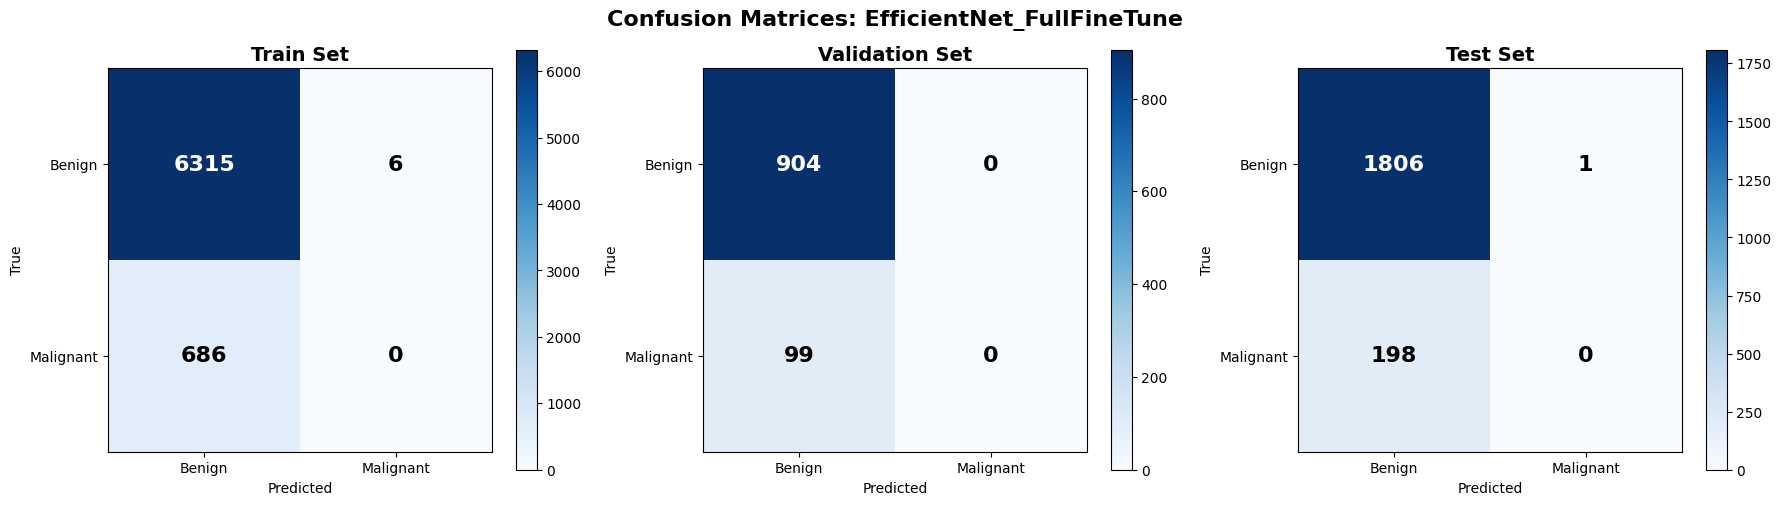


💾 Model saved: saved_models/EfficientNet_FullFineTune.h5
☁️  Uploaded to W&B


epoch/accuracy,▁▃▄▅▅▆▇▇▇▇█████
epoch/auc,▁▃▄▅▆▆▇▇▇▇█████
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▄▄▃▃▂▂▂▂▁▁▁▁▁
epoch/precision,▁▃▄▅▅▆▇▇▇▇█████
epoch/recall,▁▃▄▅▅▆▇▇▇▇█████
epoch/val_accuracy,▇█▆████▅███▇█▁▇
epoch/val_auc,▇▇▆▇▇▇▇▆▇█▇▇▇▁█
epoch/val_loss,▁▁▁▂▃▁▁▁▃▁▁▁█▁▁
+23,...


In [17]:
# ============================================================================
# EXPERIMENT: EfficientNet - Full Fine-Tuning
# ============================================================================

model = build_transfer_model(
    base_name='efficientnet',
    dropout=0.5,
    unfreeze_layers=None,
    dense_units=256
)

result_eff_1 = train_experiment(model, {
    'name': 'EfficientNet_FullFineTune',
    'architecture': 'efficientnet',
    'dropout': 0.5,
    'unfreeze_layers': 'all',
    'dense_units': 256,
    'learning_rate': 0.0001,
    'batch_size': 32,
    'epochs': 30
})


  EFFICIENTNET - last_30_layers
  Total params: 4,379,045
  Trainable params: 1,822,818 (41.6%)

EXPERIMENT: EfficientNet_PartialFineTune
  architecture: efficientnet
  dropout: 0.5
  unfreeze_layers: 30
  dense_units: 256
  learning_rate: 0.0001
  batch_size: 32
  epochs: 30




Training (max 30 epochs)...

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4936 - auc: 0.4944 - loss: 1.0902 - precision: 0.4936 - recall: 0.4936
Epoch 1: val_recall improved from -inf to 0.90130, saving model to saved_models/EfficientNet_PartialFineTune.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 61s 152ms/step - accuracy: 0.4936 - auc: 0.4944 - loss: 1.0901 - precision: 0.4936 - recall: 0.4936 - val_accuracy: 0.9013 - val_auc: 0.9180 - val_loss: 0.6592 - val_precision: 0.9013 - val_recall: 0.9013
Epoch 2/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4986 - auc: 0.5042 - loss: 1.0273 - precision: 0.4986 - recall: 0.4986
Epoch 2: val_recall did not improve from 0.90130
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.4986 - auc: 0.5043 - loss: 1.0271 - precision: 0.4986 - recall: 0.4986 - val_accuracy: 0.0987 - val_auc: 0.1281 - val_loss: 0.8410 - val_precision: 0.0987 - val_recall: 0.0987
Epoch 3/30
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5151 - auc: 0.5168 - loss: 0.9485 - precision: 0.5151 - recall: 0.5151
Epoch 3: val_recall did not improve from 0.90130
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5150 - auc: 0.5166 - loss: 0.9486 - precision: 0.5150 - recall: 0.5150 - val_accuracy: 0.9013 - val_auc:

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


📊 TRAINING SET:
   Accuracy: 0.9021
   AUC:      0.6444
   Recall:   0.0000

📊 VALIDATION SET:
   Accuracy: 0.9013
   AUC:      0.6292
   Recall:   0.0000

📊 TEST SET (FINAL):
   Accuracy:  0.9012
   AUC:       0.6152
   Recall:    0.0000 ← PRIMARY
   Precision: 0.0000
   F1:        0.0000


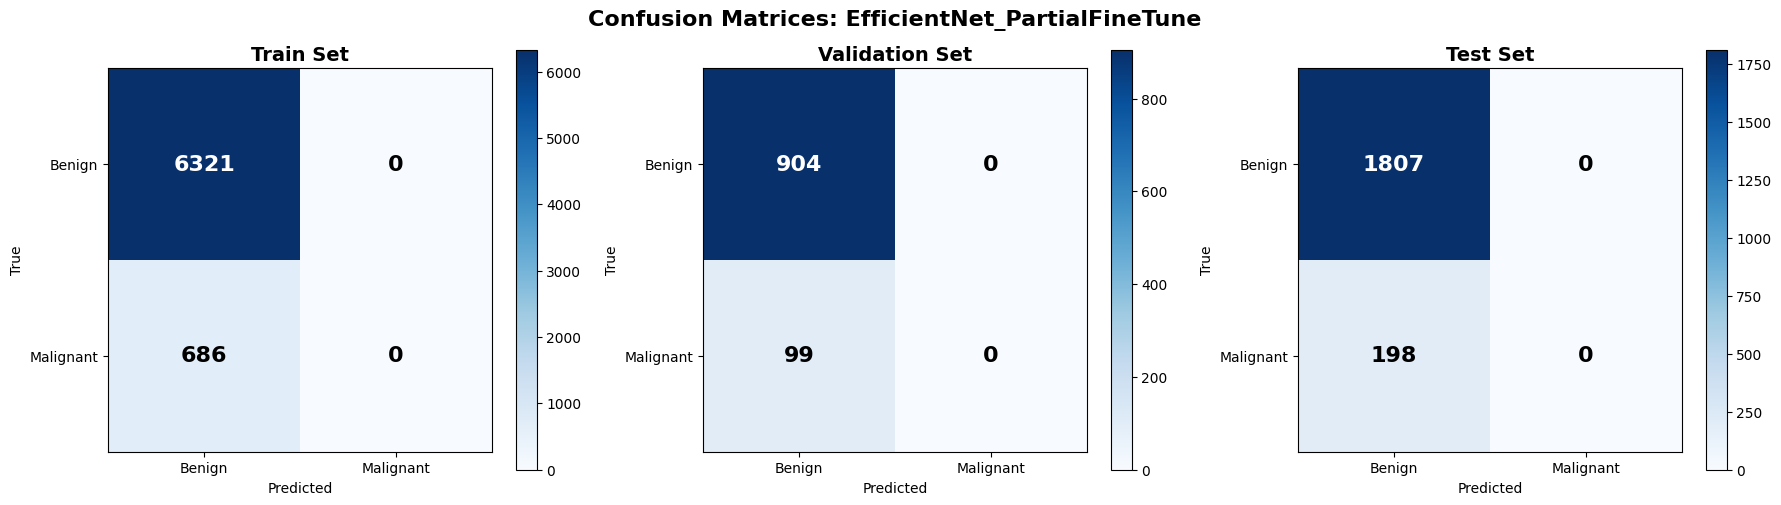


💾 Model saved: saved_models/EfficientNet_PartialFineTune.h5
☁️  Uploaded to W&B


epoch/accuracy,▁▅▅▄▄▂▇▇█▅▂
epoch/auc,▁▅▄▃▃▂██▇▄▃
epoch/epoch,▁▂▂▃▄▅▅▆▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▃▃▂▂▁▁▁
epoch/precision,▁▅▅▄▄▂▇▇█▅▂
epoch/recall,▁▅▅▄▄▂▇▇█▅▂
epoch/val_accuracy,█▁█▁█▁▇▁██▅
epoch/val_auc,█▁█▁█▁▇▁██▅
epoch/val_loss,▃▇▁█▃▅▄▆▃▃▄
+23,...


In [18]:
# ============================================================================
# EXPERIMENT: EfficientNet - Your Configuration
# ============================================================================

model = build_transfer_model(
    base_name='efficientnet',
    dropout=0.5,
    unfreeze_layers=30,
    dense_units=256
)

result_eff_2 = train_experiment(model, {
    'name': 'EfficientNet_PartialFineTune',
    'architecture': 'efficientnet',
    'dropout': 0.5,
    'unfreeze_layers': 30,
    'dense_units': 256,
    'learning_rate': 0.0001,
    'batch_size': 32,
    'epochs': 30
})

---
## 📊 Compare All Your Experiments

In [19]:
# Collect all results (add your experiment names here)
all_results = [
    result_cnn_1,
    # result_cnn_2,  # Uncomment after running
    # result_resnet_1,
    # result_resnet_2,
    # result_vgg_1,
    # result_vgg_2,
    # result_eff_1,
    # result_eff_2,
]

# Create comparison DataFrame
comparison_data = []
for r in all_results:
    comparison_data.append({
        'Experiment': r['name'],
        'Train_Recall': f"{r['train_metrics']['train/recall_malignant']:.4f}",
        'Val_Recall': f"{r['val_metrics']['val/recall_malignant']:.4f}",
        'Test_Recall': f"{r['test_metrics']['test/recall_malignant']:.4f}",
        'Train_AUC': f"{r['train_metrics']['train/auc']:.4f}",
        'Val_AUC': f"{r['val_metrics']['val/auc']:.4f}",
        'Test_AUC': f"{r['test_metrics']['test/auc']:.4f}",
        'Test_Precision': f"{r['test_metrics']['test/precision_malignant']:.4f}",
        'Test_F1': f"{r['test_metrics']['test/f1_malignant']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*120)
print("COMPREHENSIVE COMPARISON - ALL SPLITS")
print("="*120 + "\n")
print(comparison_df.to_string(index=False))

# Find best
best_idx = comparison_df['Test_Recall'].astype(float).argmax()
print(f"\n🏆 BEST MODEL: {comparison_df.iloc[best_idx]['Experiment']}")
print(f"   Test Recall: {comparison_df.iloc[best_idx]['Test_Recall']}")
print(f"   Test AUC: {comparison_df.iloc[best_idx]['Test_AUC']}")

# Save
comparison_df.to_csv('all_experiments_comparison.csv', index=False)
print(f"\n💾 Saved to: all_experiments_comparison.csv")


COMPREHENSIVE COMPARISON - ALL SPLITS

  Experiment Train_Recall Val_Recall Test_Recall Train_AUC Val_AUC Test_AUC Test_Precision Test_F1
CNN_Baseline       0.6720     0.6667      0.6919    0.9484  0.9348   0.9394         0.5352  0.6035

🏆 BEST MODEL: CNN_Baseline
   Test Recall: 0.6919
   Test AUC: 0.9394

💾 Saved to: all_experiments_comparison.csv


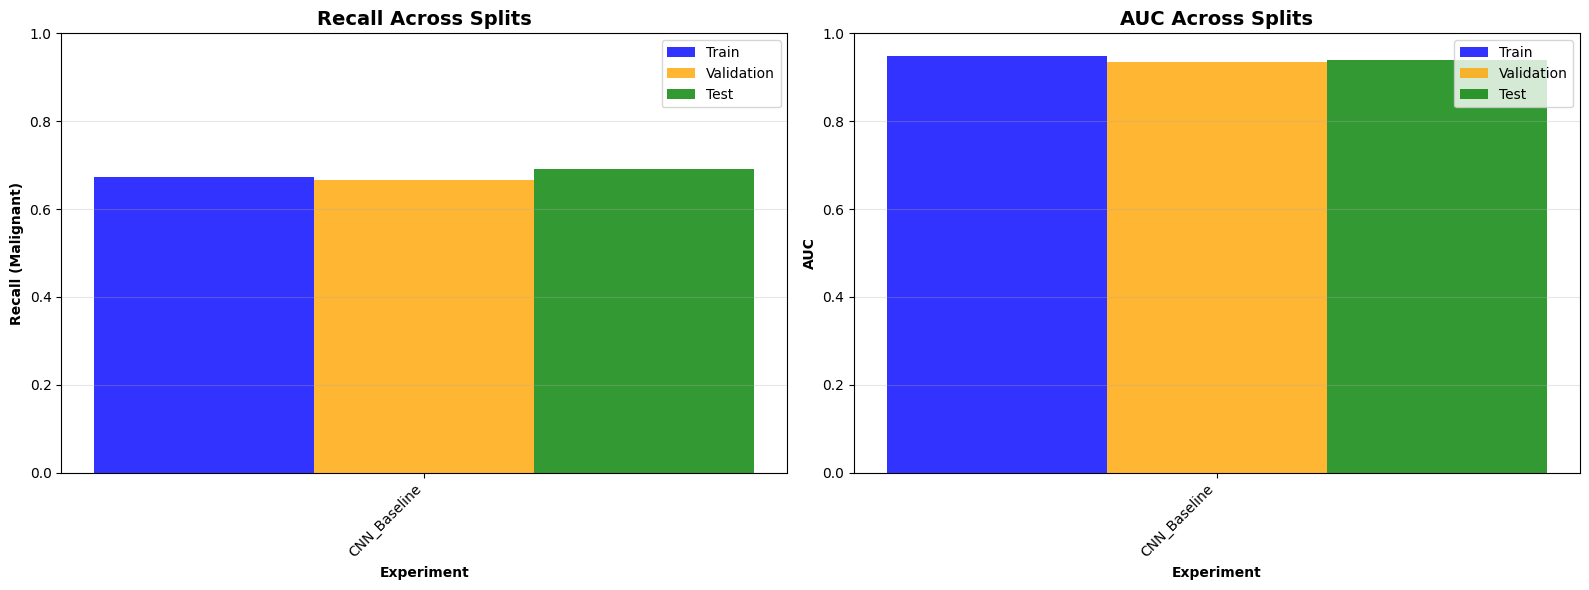

📊 Saved: train_val_test_comparison.png


In [20]:
# Visualize Train/Val/Test comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Recall across splits
x = np.arange(len(comparison_df))
width = 0.25

axes[0].bar(x - width, comparison_df['Train_Recall'].astype(float), width,
           label='Train', alpha=0.8, color='blue')
axes[0].bar(x, comparison_df['Val_Recall'].astype(float), width,
           label='Validation', alpha=0.8, color='orange')
axes[0].bar(x + width, comparison_df['Test_Recall'].astype(float), width,
           label='Test', alpha=0.8, color='green')

axes[0].set_xlabel('Experiment', fontweight='bold')
axes[0].set_ylabel('Recall (Malignant)', fontweight='bold')
axes[0].set_title('Recall Across Splits', fontweight='bold', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Experiment'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot 2: AUC across splits
axes[1].bar(x - width, comparison_df['Train_AUC'].astype(float), width,
           label='Train', alpha=0.8, color='blue')
axes[1].bar(x, comparison_df['Val_AUC'].astype(float), width,
           label='Validation', alpha=0.8, color='orange')
axes[1].bar(x + width, comparison_df['Test_AUC'].astype(float), width,
           label='Test', alpha=0.8, color='green')

axes[1].set_xlabel('Experiment', fontweight='bold')
axes[1].set_ylabel('AUC', fontweight='bold')
axes[1].set_title('AUC Across Splits', fontweight='bold', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Experiment'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('train_val_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Saved: train_val_test_comparison.png")

---
## 📖 Guide: How to Use This Notebook

### **Step-by-Step Workflow**:

#### **1. Start with Baselines**
Run one experiment from each group:
- Custom CNN baseline
- ResNet50 full fine-tune
- VGG16 full fine-tune
- EfficientNet full fine-tune

**Time**: ~2 hours total

#### **2. Check W&B Dashboard**
Go to https://wandb.ai → Your project

**Look for**:
- Which architecture has best test recall?
- Is there overfitting? (train >> val/test)
- Training stability (smooth curves?)

#### **3. Tune Best Architecture**
Focus on the winning architecture. Try:

**If Custom CNN won**:
- Try wider (more filters)
- Try deeper (more blocks)
- Adjust dropout

**If Transfer Learning won**:
- Try partial fine-tuning (fewer layers)
- Adjust learning rate
- Try different dropout

#### **4. Iterate**
Based on W&B results:
- Copy experiment cell
- Change ONE parameter
- Run and compare

**Goal**: Find best config for each architecture

---

### **Parameters to Tune** (by architecture)

#### **Custom CNN**:
```python
# Architecture parameters:
filters_base: 16, 32, 64, 128       # Starting filters (doubles each layer)
depth: 2, 3, 4                       # Number of conv blocks
dropout: 0.3, 0.5, 0.7              # Regularization strength
dense_units: 256, 512, 1024         # Dense layer size

# Training parameters:
learning_rate: 0.0001, 0.001, 0.01  # ⚠️ VERY IMPORTANT!
                                     # 0.0001 = slow but stable
                                     # 0.001  = good default (recommended start)
                                     # 0.01   = fast but may diverge
batch_size: 32, 64, 128             # Larger = faster, more memory
```

**Learning Rate Tips for CNN**:
- **Start with 0.001** (proven baseline)
- **Try 0.01** if training is slow/stuck
- **Try 0.0001** if loss oscillates/diverges
- Watch W&B training curves to decide!

#### **ResNet50/VGG16/EfficientNet**:
```python
unfreeze_layers: None (all), 10, 20, 50, 100
dropout: 0.3, 0.5, 0.7
dense_units: 128, 256, 512
learning_rate: 0.00001, 0.0001, 0.001  # LOWER for fine-tuning!
batch_size: 16, 32  # Smaller for big models
```

---

### **Understanding the Metrics**

#### **Train vs Val vs Test**:

```
Train:      Model sees during training
Validation: Used for early stopping & hyperparameter tuning
Test:       FINAL evaluation (report this!)
```

#### **What to Look For**:

**Good**:
```
Train:  90% recall
Val:    88% recall  ← Close to train
Test:   87% recall  ← Close to val
```
→ Model generalizes well!

**Overfitting**:
```
Train:  95% recall  ← Very high
Val:    75% recall  ← Much lower
Test:   74% recall
```
→ Need more dropout or regularization

**Underfitting**:
```
Train:  70% recall  ← Low even on train
Val:    69% recall
Test:   68% recall
```
→ Model not powerful enough or LR too low

---

### **W&B Dashboard Tips**

#### **Compare Experiments**:
1. Select multiple runs (checkbox)
2. Click "Compare"
3. See metrics side-by-side

#### **Parallel Coordinates**:
- Shows all hyperparameters vs metrics
- Find patterns (e.g., "dropout 0.7 always worse")

#### **Training Curves**:
- Overlay multiple experiments
- See which converges faster
- Check for overfitting

---

### **Recommended Testing Order**

**Phase 1: Architecture Selection** (~2-3 hours)
```
1. CNN_Baseline
2. ResNet50_FullFineTune
3. VGG16_FullFineTune
4. EfficientNet_FullFineTune

→ Pick winner
```

**Phase 2: Hyperparameter Tuning** (~2-3 hours)
```
Focus on winner from Phase 1
Try 3-4 variations:
- Different dropout
- Different learning rate
- Different architecture params

→ Find optimal config
```

**Phase 3: Final Validation** (~30 min)
```
Train best config one more time
Save model
Report test metrics
```

**Total**: 5-7 hours of compute, ~8-10 experiments

---

## 💾 Download Everything

In [21]:
from google.colab import files

# Package everything
!zip -r dermamnist_results.zip saved_models/ *.csv *.png

print("📦 Packaged:")
print("  - All saved models")
print("  - Comparison tables (CSV)")
print("  - Comparison plots (PNG)")
print("\nDownloading...")

files.download('dermamnist_results.zip')

print("\n✅ Complete!")
print("\n🌐 Check W&B for interactive results: https://wandb.ai")

  adding: saved_models/ (stored 0%)
  adding: saved_models/ResNet50_FullFineTune.h5 (deflated 8%)
  adding: saved_models/CNN_HighLR.h5 (deflated 8%)
  adding: saved_models/ResNet50_PartialFineTune.h5 (deflated 12%)
  adding: saved_models/VGG16_PartialFineTune.h5 (deflated 15%)
  adding: saved_models/CNN_Wider.h5 (deflated 8%)
  adding: saved_models/EfficientNet_FullFineTune.h5 (deflated 10%)
  adding: saved_models/VGG16_FullFineTune.h5 (deflated 13%)
  adding: saved_models/CNN_Baseline.h5 (deflated 9%)
  adding: saved_models/EfficientNet_PartialFineTune.h5 (deflated 9%)
  adding: all_experiments_comparison.csv (deflated 31%)
  adding: train_val_test_comparison.png (deflated 24%)
📦 Packaged:
  - All saved models
  - Comparison tables (CSV)
  - Comparison plots (PNG)

Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Complete!

🌐 Check W&B for interactive results: https://wandb.ai
